In [67]:
# Import requirement libraries and tools for visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer
from termcolor import colored
from random import uniform

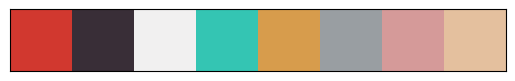

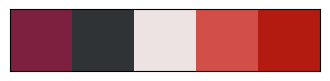

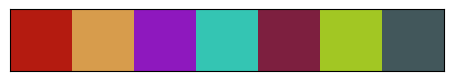

In [68]:
def custom_palette(custom_colors):
    """Show color palette that use in this notebook"""
    customPalette = sns.set_palette(sns.color_palette(custom_colors))
    sns.palplot(sns.color_palette(custom_colors),size=0.8)
    plt.tick_params(axis='both', labelsize=0, length = 0)

 # for plot title
FONT = {'fontsize':30, 'fontstyle':'normal', 'fontfamily':'Georgia', 'backgroundcolor':'#B41B10', 'color':'#E4C09E'}

# Create List of Color Palletes
colors1 = ["#D1382F", "#392E37", "#F1F0F0", "#34C5B3", "#D79C4C", "#999EA2", "#D59A99", "#E4C09E"]
colors2 = ["#7D1F3F","#303336","#ECE3E2","#D24E49","#B41B10"]
dark_colors = ["#B41B10", "#D79C4C", "#8e18be", "#34C5B3", "#7D1F3F", "#a2c723", "#42575B"]
# Plot Color Palletes
for color in [colors1, colors2, dark_colors]:
    custom_palette(color)

In [69]:
df = pd.read_csv(r'C:\Users\DELL\Downloads\Telegram Desktop\Customer_data.csv')
df.head()

,cust_id,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [70]:
df.shape

(8950, 18)

In [71]:
#drop cust_id
df = df.drop('cust_id', axis = 1)


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   balance                           8950 non-null   float64
 1   balance_frequency                 8950 non-null   float64
 2   purchases                         8950 non-null   float64
 3   oneoff_purchases                  8950 non-null   float64
 4   installments_purchases            8950 non-null   float64
 5   cash_advance                      8950 non-null   float64
 6   purchases_frequency               8950 non-null   float64
 7   oneoff_purchases_frequency        8950 non-null   float64
 8   purchases_installments_frequency  8950 non-null   float64
 9   cash_advance_frequency            8950 non-null   float64
 10  cash_advance_trx                  8950 non-null   int64  
 11  purchases_trx                     8950 non-null   int64  
 12  credit

In [73]:
df.isnull().sum()

balance                               0
balance_frequency                     0
purchases                             0
oneoff_purchases                      0
installments_purchases                0
cash_advance                          0
purchases_frequency                   0
oneoff_purchases_frequency            0
purchases_installments_frequency      0
cash_advance_frequency                0
cash_advance_trx                      0
purchases_trx                         0
credit_limit                          1
payments                              0
minimum_payments                    313
prc_full_payment                      0
tenure                                0
dtype: int64

In [74]:
df = df.drop(df[df.credit_limit.isna()].index, axis=0)

In [75]:
# Fill the remaining missing values with KNNimputer()
# Define imputer
imputer = KNNImputer()
# Fit on the dataset
imputer.fit(df)
# Transform the dataset
df1 = pd.DataFrame(imputer.transform(df),columns=df.columns)

# Print result
print(colored(f'Missing (before): {df.isna().sum().sum()}', 'red'))
print(colored(f'Missing (after): {df1.isna().sum().sum()}', 'green'))   

Missing (before): 313
Missing (after): 0


In [76]:
df1.head()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,379.829982,0.000000,12.0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0


In [77]:
df1.shape

(8949, 17)

C:\Users\pron\AppData\Local\Temp\ipykernel_10652\3225825748.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x=col, palette=custom_palette, saturation=1, linewidth=2, ax=ax[i//2, i%2])
C:\Users\pron\AppData\Local\Temp\ipykernel_10652\3225825748.py:10: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.boxplot(data=df1, x=col, palette=custom_palette, saturation=1, linewidth=2, ax=ax[i//2, i%2])
C:\Users\pron\AppData\Local\Temp\ipykernel_10652\3225825748.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x=col, palette=custom_palette, saturation=1, linewidth=2, ax=ax[i//2, i%2])
C:\Users\pron\AppData\Local\Temp\ipyker

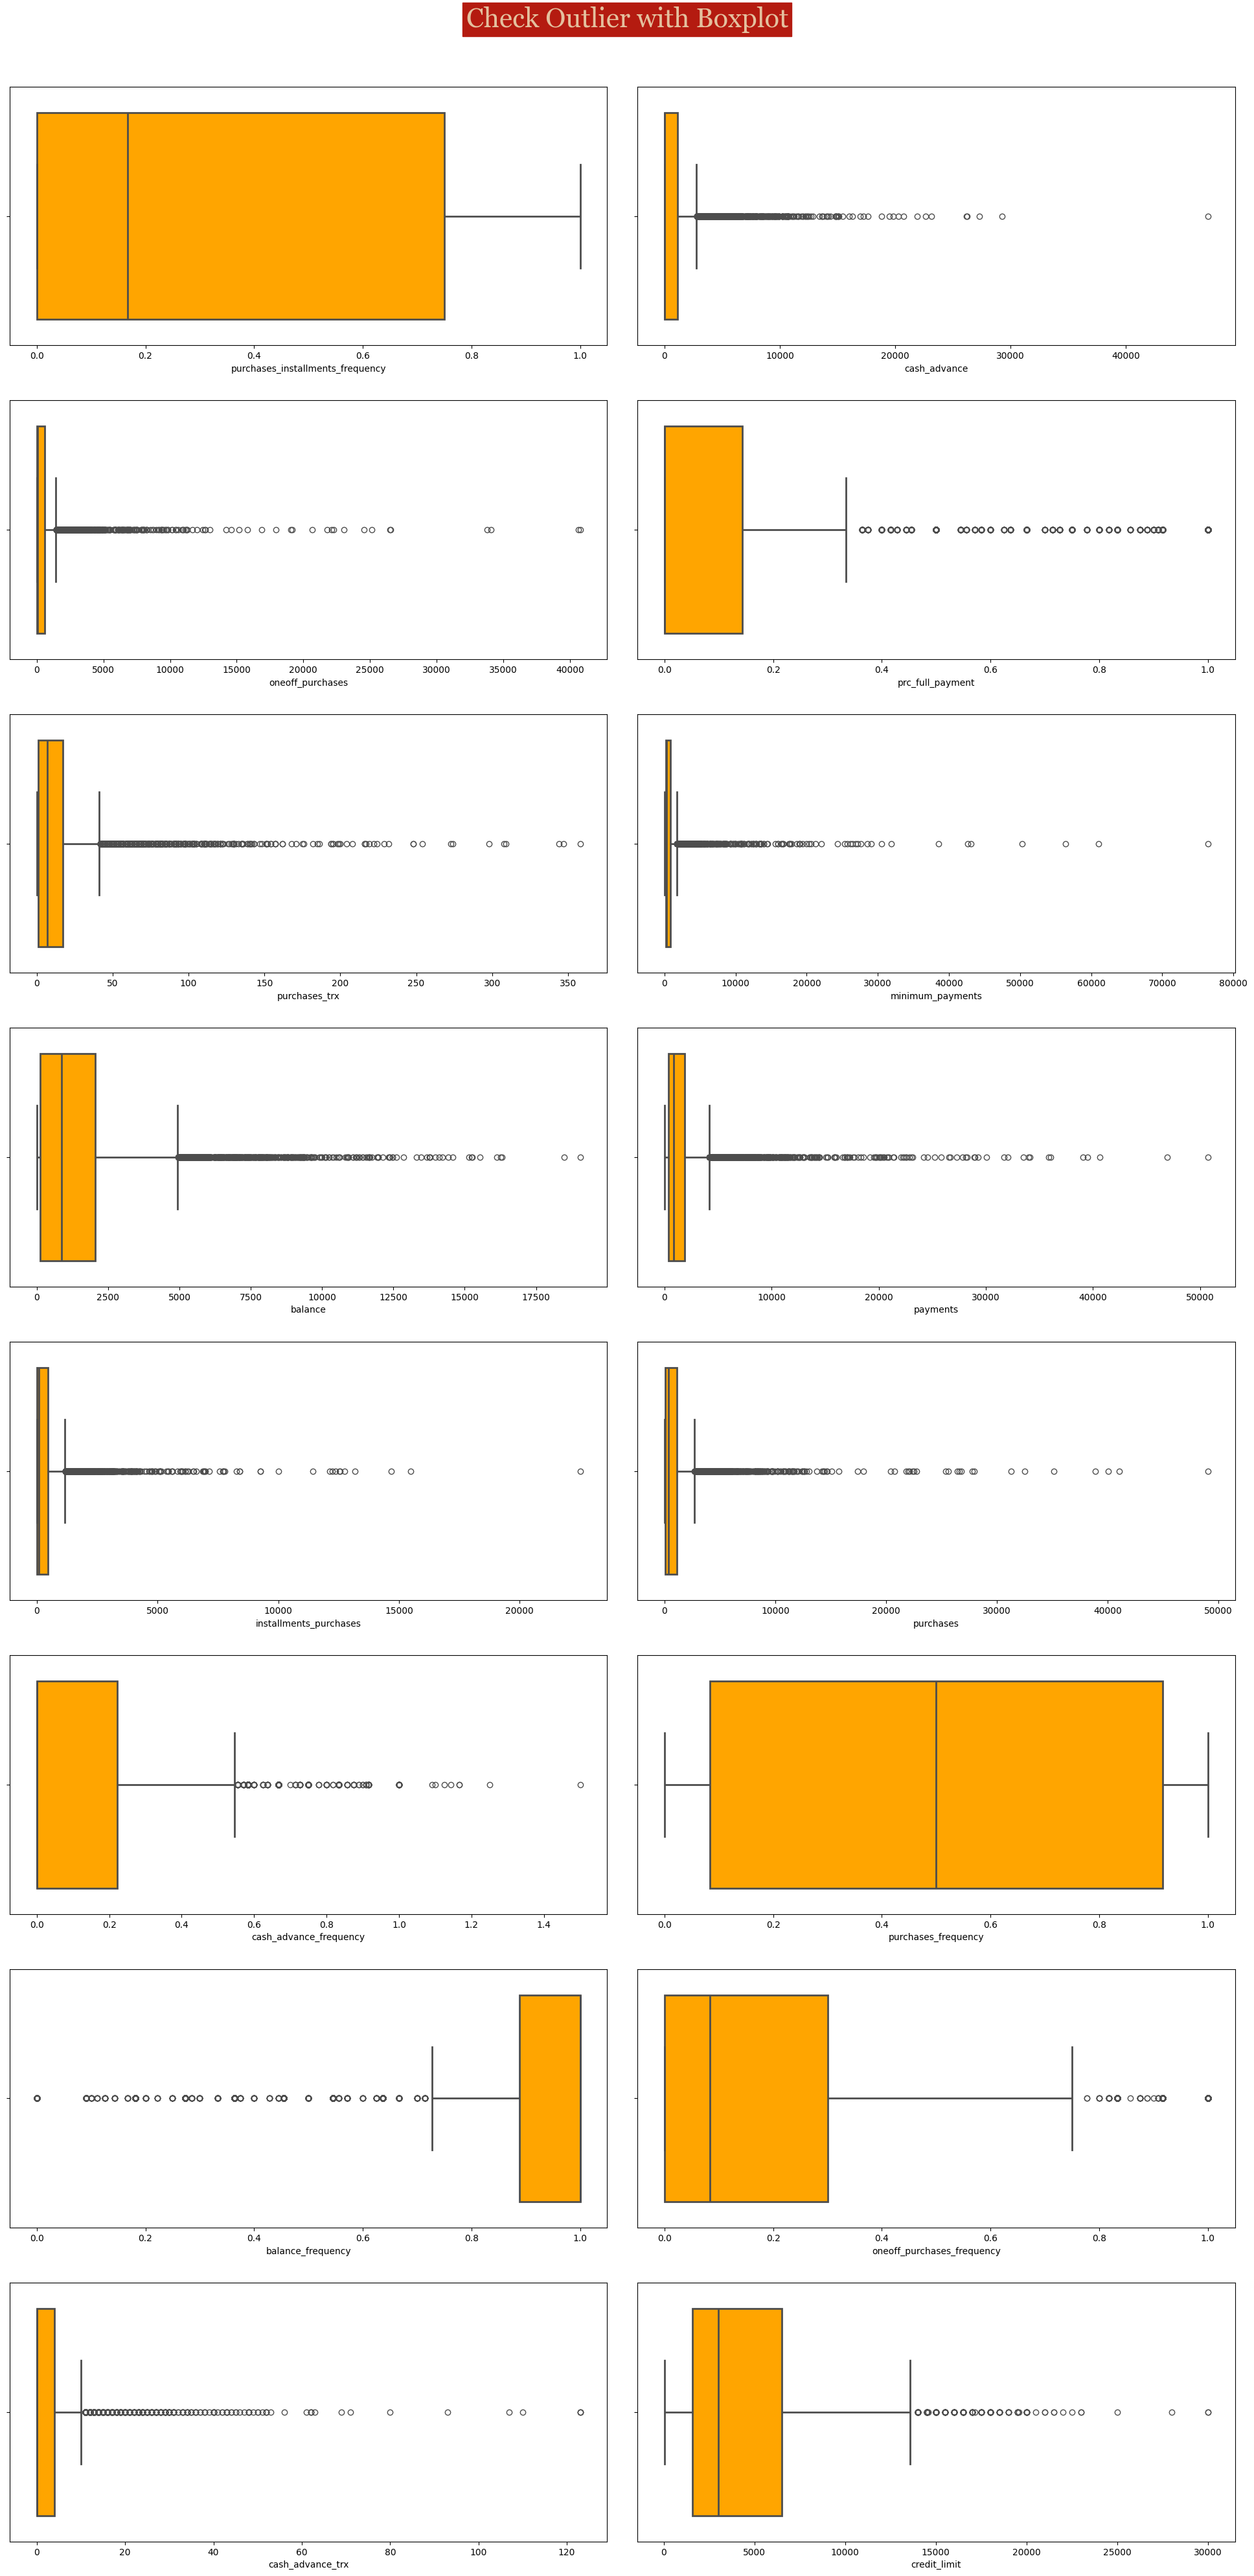

In [47]:


# Define a custom palette from orange to blue-white
custom_palette = sns.color_palette(["#FFA500", "#87CEFA", "#FFFFFF"])

fig, ax = plt.subplots(8, 2, figsize=(20, 40))

# Exclude 'tenure' column
columns_to_plot = list(set(df1.columns) - set(['tenure']))

for i, col in enumerate(columns_to_plot):
    sns.boxplot(data=df1, x=col, palette=custom_palette, saturation=1, linewidth=2, ax=ax[i//2, i%2])

plt.suptitle("Check Outlier with Boxplot", y=1, **FONT)
plt.tight_layout(pad=3.0)
plt.show()


### Univariate

IndexError: index 8 is out of bounds for axis 0 with size 8

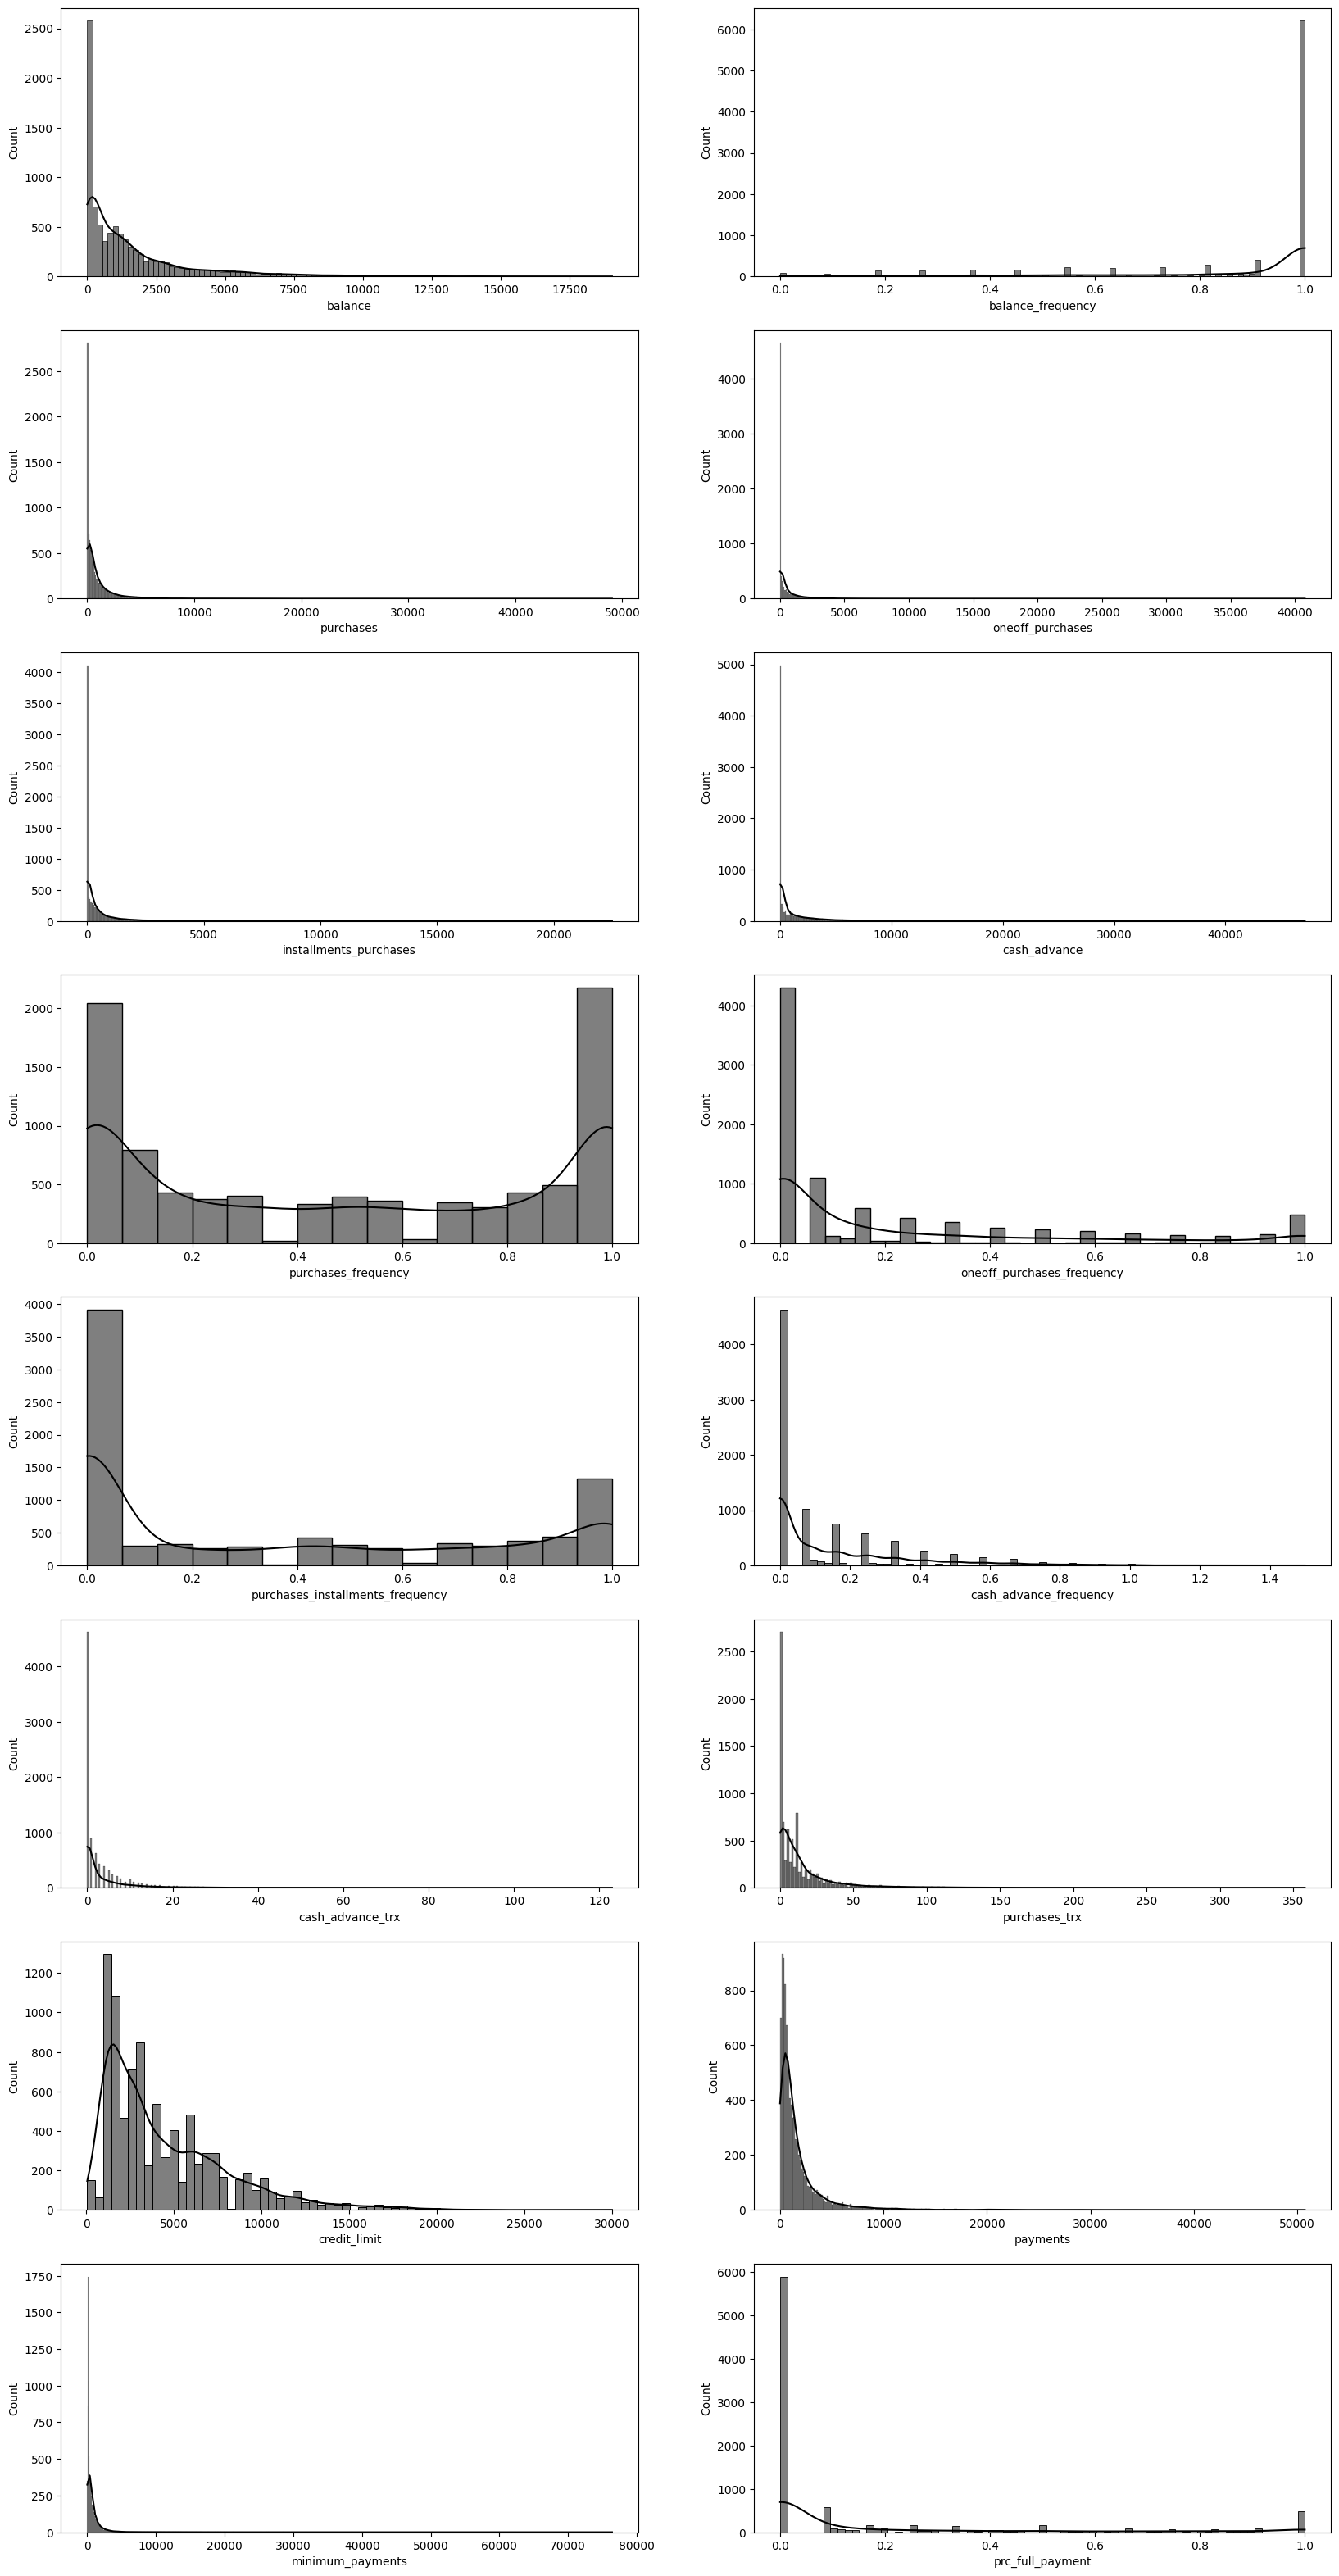

In [48]:
fig, ax = plt.subplots(8, 2, figsize=(20, 40))
for i, col in enumerate(df1):
    sns.histplot(df1[col], kde=True, ax=ax[i//2, i%2], color='black')
    
fig.suptitle('Distribution of Columns',y=1.002, **FONT)
fig.tight_layout()
plt.show()

### Bivariate

c:\Users\pron\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\pron\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\pron\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\pron\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\pron\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigne

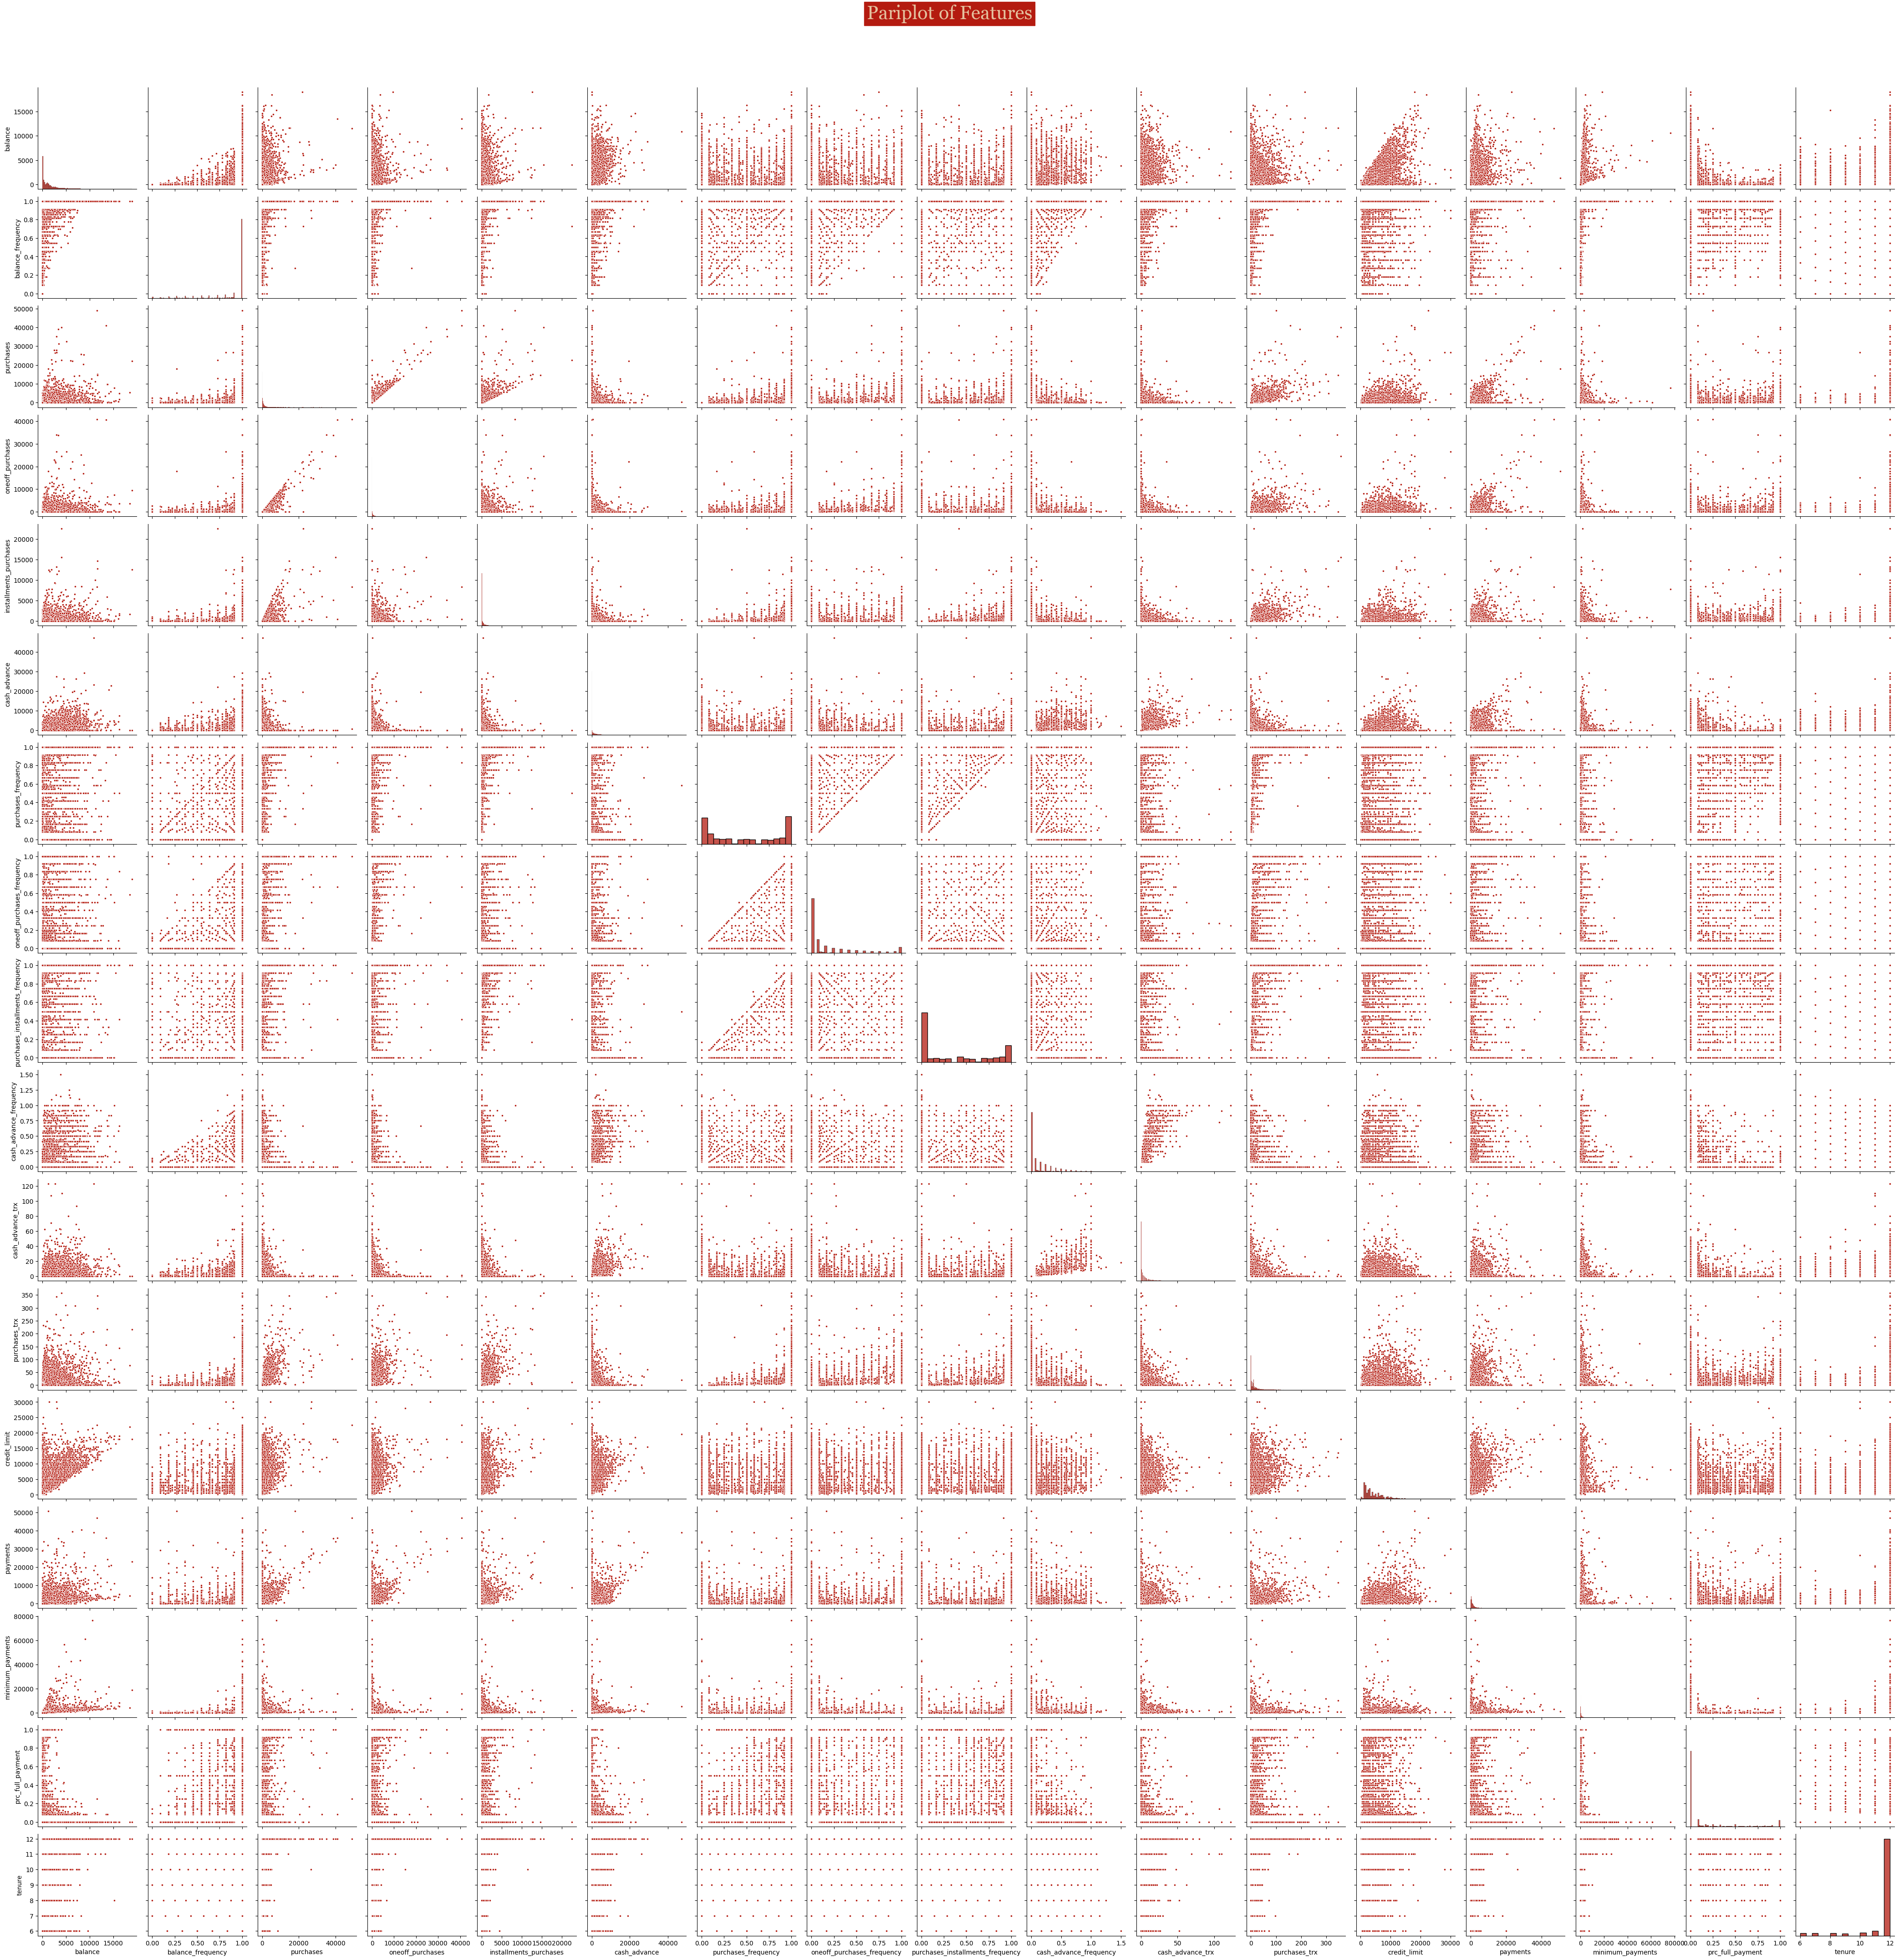

In [ ]:
# Draw pair plot for EDA
pplot = sns.pairplot(df1, palette="#B41B10", markers='.')
pplot.fig.suptitle("Pariplot of Features", y=1.02, **FONT)
pplot.tight_layout()
plt.show()

### Multivariate

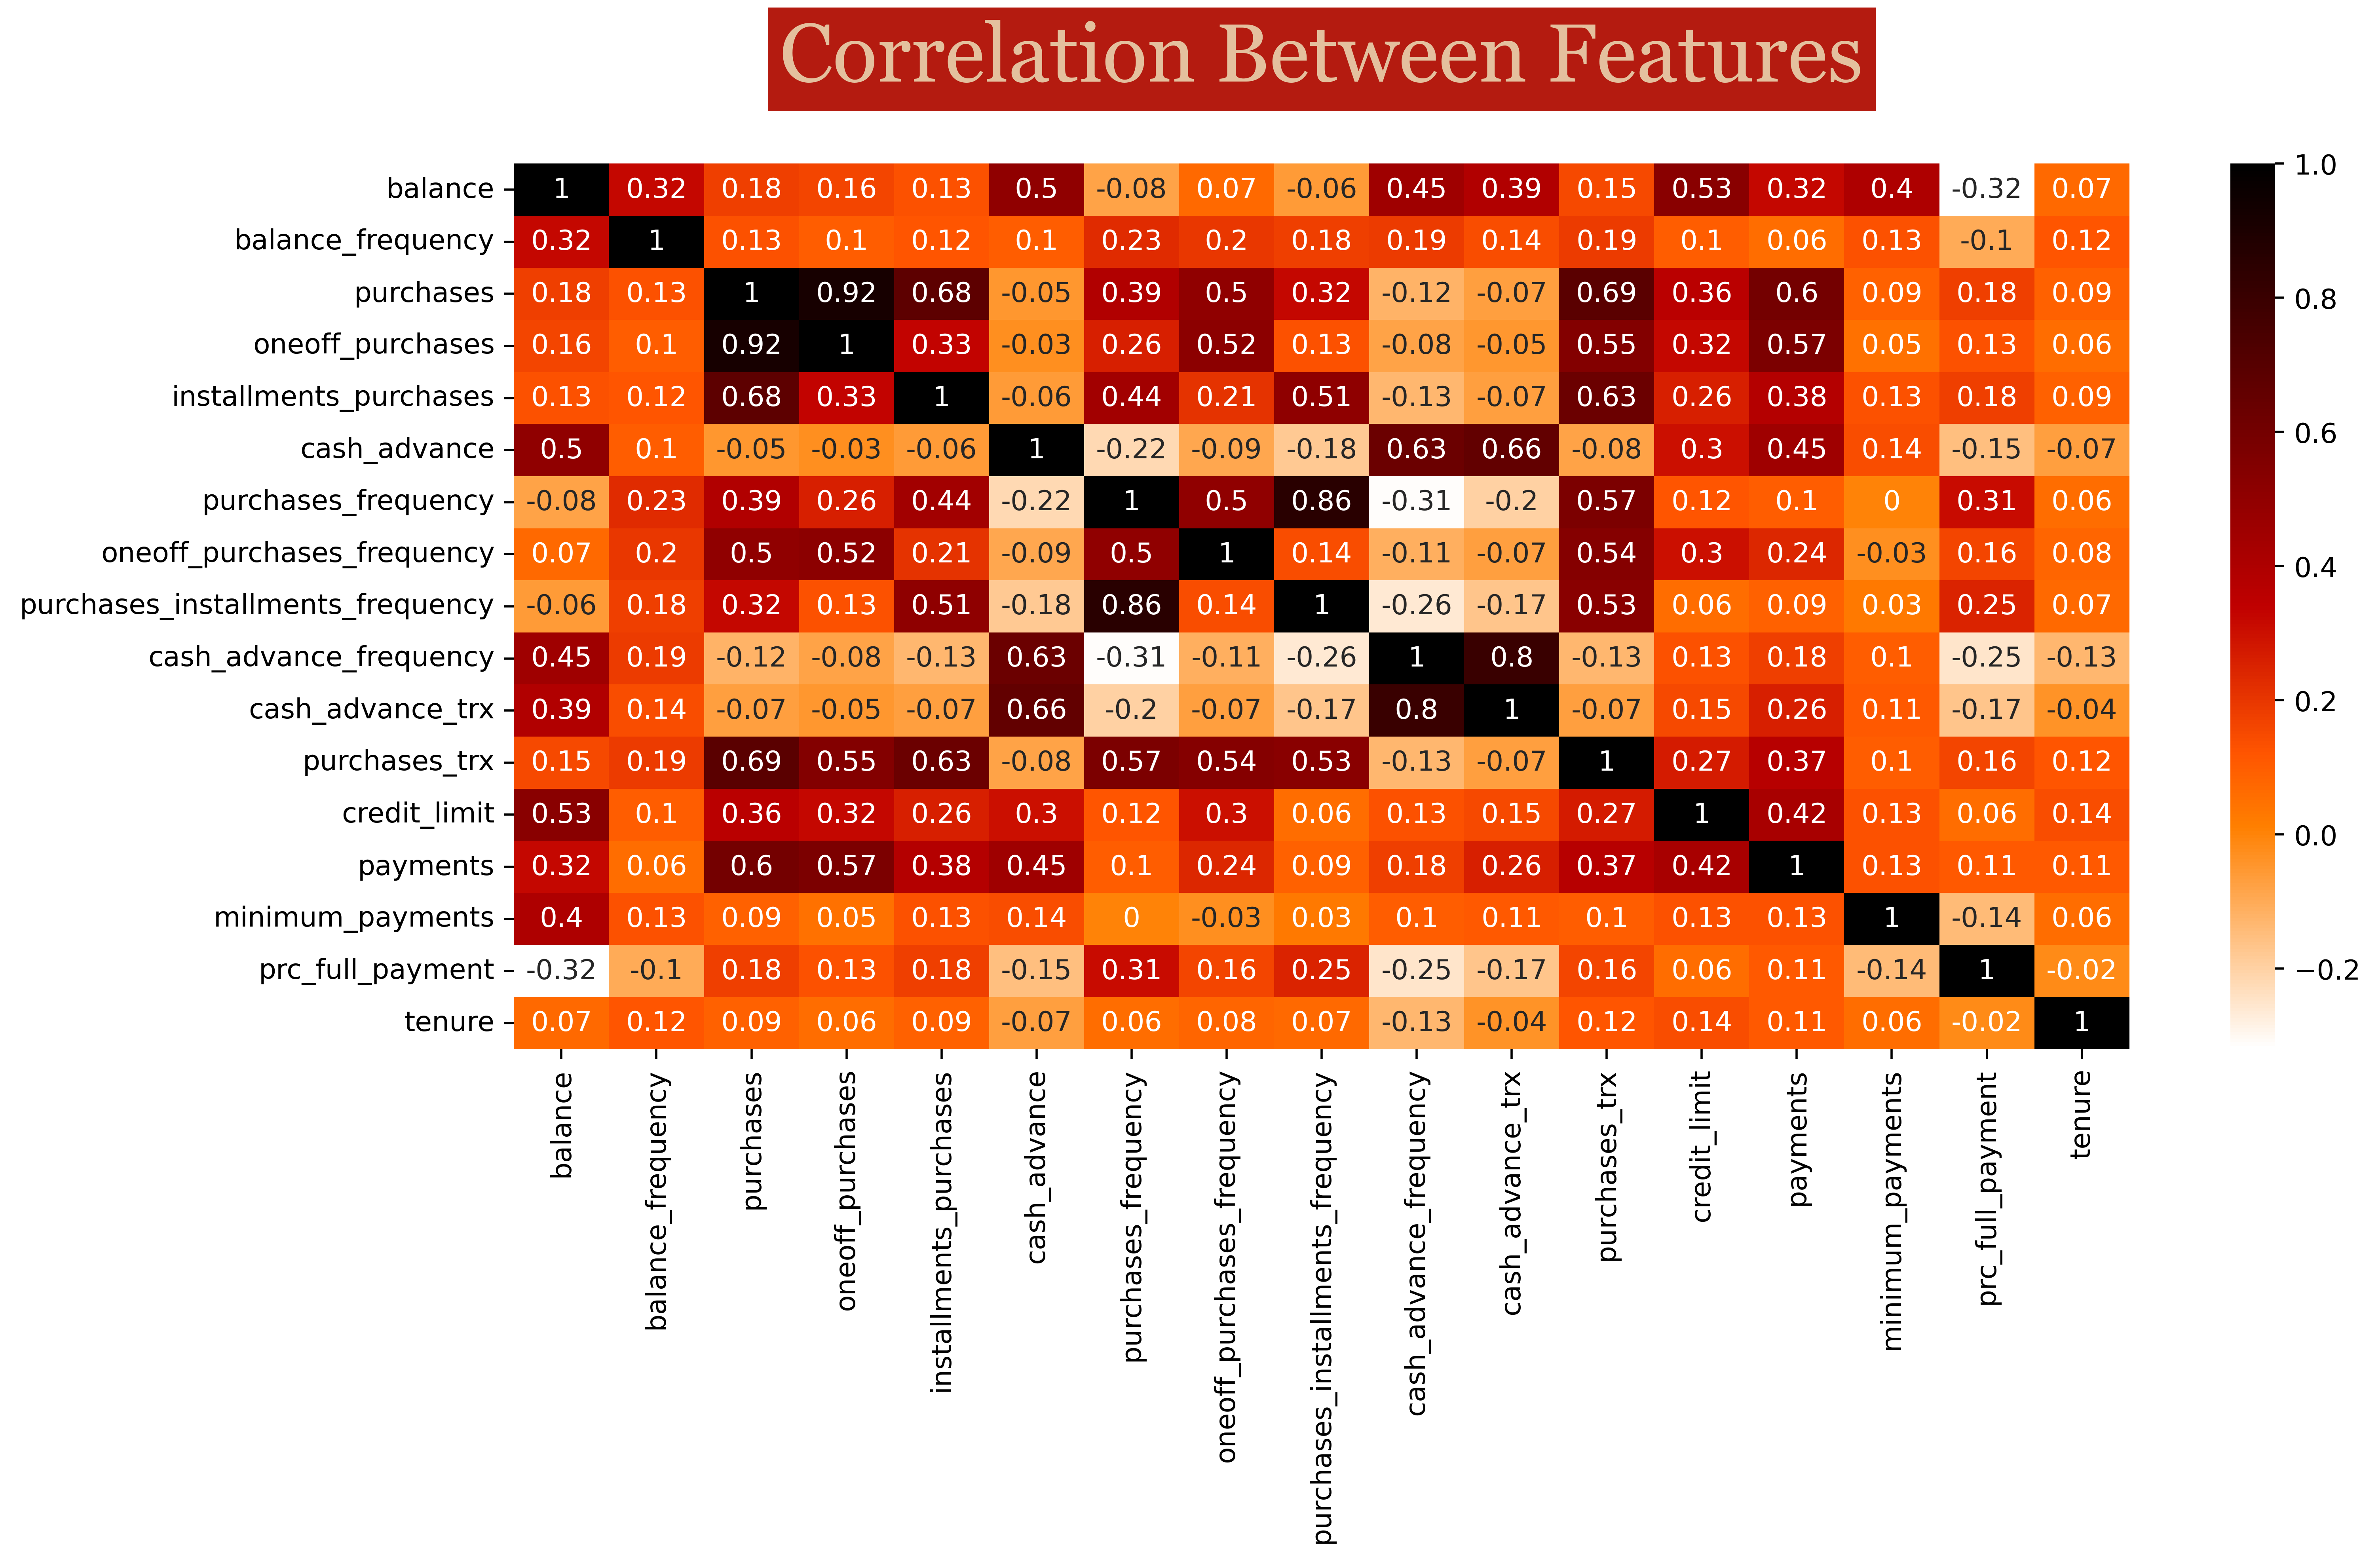

In [ ]:
# Correlation between features
plt.figure(figsize=(13,8), dpi=500)
sns.heatmap(round(df.corr(),2), annot=True, cmap='gist_heat_r')
plt.title("Correlation Between Features", pad=30, fontdict=FONT)
plt.tight_layout()
plt.show()

### Clustering Building

In [78]:
#Feature scaled
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df1)
df_scaled = pd.DataFrame(df_scaled, columns=df1.columns)

In [79]:
df_scaled.head()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
0,-0.732054,-0.249881,-0.424934,-0.356957,-0.349114,-0.466805,-0.806649,-0.678716,-0.707409,-0.675294,-0.476083,-0.511381,-0.960380,-0.529026,-0.303869,-0.525588,0.360541
1,0.786858,0.134049,-0.469584,-0.356957,-0.454607,2.605438,-1.221928,-0.678716,-0.917090,0.573949,0.110032,-0.591841,0.688601,0.818546,0.093483,0.234159,0.360541
2,0.447041,0.517980,-0.107716,0.108843,-0.454607,-0.466805,1.269742,2.673295,-0.917090,-0.675294,-0.476083,-0.109082,0.826016,-0.383857,-0.096095,-0.525588,0.360541
3,0.049015,-1.017743,0.231995,0.546123,-0.454607,-0.368678,-1.014290,-0.399383,-0.917090,-0.258882,-0.329554,-0.551611,0.826016,-0.598733,-0.201502,-0.525588,0.360541
4,-0.358849,0.517980,-0.462095,-0.347317,-0.454607,-0.466805,-1.014290,-0.399383,-0.917090,-0.675294,-0.476083,-0.551611,-0.905414,-0.364421,-0.259023,-0.525588,0.360541


In [80]:
X_train = pd.DataFrame(df_scaled)

In [81]:
from sklearn.cluster import KMeans

In [82]:
X_train = df_scaled[["balance" , "purchases"]]

In [83]:
X_train.head()

,balance,purchases
0,-0.732054,-0.424934
1,0.786858,-0.469584
2,0.447041,-0.107716
3,0.049015,0.231995
4,-0.358849,-0.462095


In [84]:
X_train.shape

(8949, 2)

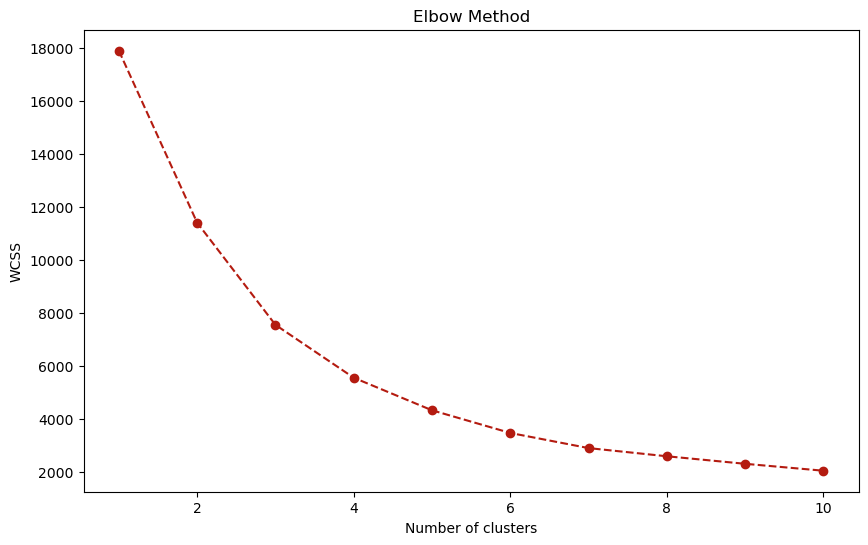

In [85]:
#plot elbow
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=3, random_state=0)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [86]:
# Euclidean function
def euclidean(point, data):
  """
  Euclidean distance between point and data
  Point has dimension (n, )
  Data has dimension (m, n)
  Out will be of size (m, )
  """
  return np.sqrt(np.sum((point - data)**2, axis=1))

In [87]:
class KMeans:
    def __init__(self, n_clusters=8, max_iter=300):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
    
    def fit(self, X_train):
        # Convert DataFrame to numpy array
        X_train = X_train.values
        
        # Randomly select centroid start points
        min_, max_ = np.min(X_train, axis=0), np.max(X_train, axis=0)
        self.centroids = np.array([np.random.uniform(min_, max_) for _ in range(self.n_clusters)])
        
        print("Initial Centroids:", self.centroids)
        
        # Iterate, adjusting centroids until converged or until passes max_iter
        iteration = 0
        prev_centroids = None
        while prev_centroids is None or np.not_equal(self.centroids, prev_centroids).any() and iteration < self.max_iter:
            # Sort each data point, assigning to nearest centroid
            sorted_points = [[] for _ in range(self.n_clusters)]
            for x in X_train:
                dists = euclidean(x, self.centroids)
                centroid_idx = np.argmin(dists)
                sorted_points[centroid_idx].append(x)
            
            # Push current centroid to previous, reassign centroids as mean of the points
            prev_centroids = self.centroids
            self.centroids = np.array([np.mean(cluster, axis=0) if len(cluster) > 0 else prev_centroids[i] for i, cluster in enumerate(sorted_points)])
            iteration += 1
            
            print(f"Iteration {iteration}: Centroids:\n", self.centroids)
    
    def evaluate(self, X):
        X = X.values
        centroids = []
        centroid_idxs = []
        for x in X:
            dists = euclidean(x, self.centroids)
            centroid_idx = np.argmin(dists)
            centroids.append(self.centroids[centroid_idx])
            centroid_idxs.append(centroid_idx)
        return np.array(centroids), centroid_idxs


Initial Centroids: [[ 8.18634989 17.00774639]
 [ 2.89171663  7.73328535]]
Iteration 1: Centroids:
 [[ 2.49587860e+00  1.79945954e+01]
 [-1.67452438e-03 -1.20728584e-02]]
Iteration 2: Centroids:
 [[ 2.00046420e+00  1.29166814e+01]
 [-4.93001147e-03 -3.18323055e-02]]
Iteration 3: Centroids:
 [[ 2.02650175e+00  1.16392646e+01]
 [-6.36050319e-03 -3.65317128e-02]]
Iteration 4: Centroids:
 [[ 1.87069743e+00  1.06586871e+01]
 [-7.13446019e-03 -4.06500685e-02]]
Iteration 5: Centroids:
 [[ 1.89678425e+00  9.96609820e+00]
 [-8.30242264e-03 -4.36226520e-02]]
Iteration 6: Centroids:
 [[ 1.89258837  8.79017124]
 [-0.01084761 -0.05038197]]
Iteration 7: Centroids:
 [[ 1.69849348  7.84355846]
 [-0.01261967 -0.05827703]]
Iteration 8: Centroids:
 [[ 1.65736881  6.88411252]
 [-0.01645959 -0.06836722]]
Iteration 9: Centroids:
 [[ 1.6509037   6.17073896]
 [-0.02073436 -0.07750079]]
Iteration 10: Centroids:
 [[ 1.56213781  5.51878386]
 [-0.02500697 -0.08834565]]
Iteration 11: Centroids:
 [[ 1.61690506  5.02

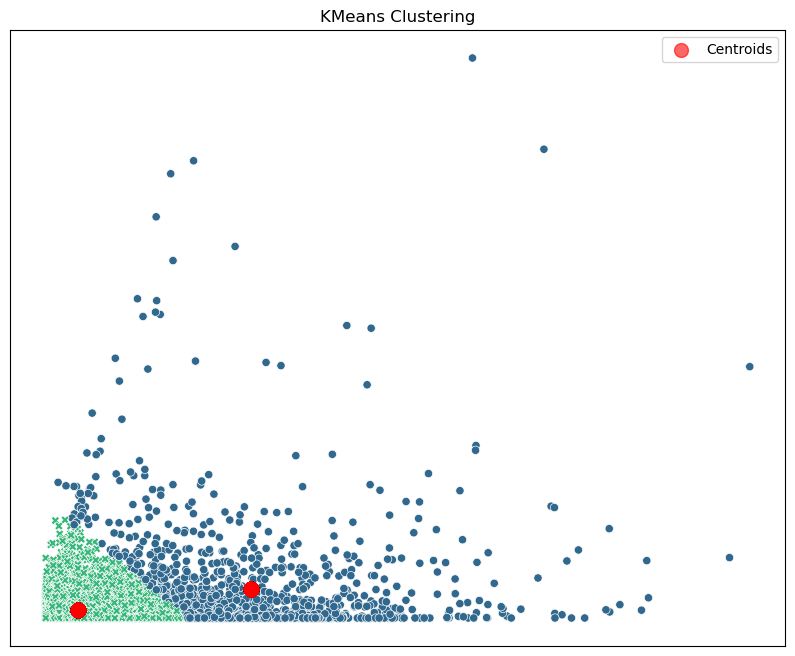

In [88]:
# K = 2

kmeans = KMeans(n_clusters=2)
kmeans.fit(X_train)
centroids, cluster_idxs = kmeans.evaluate(X_train)

# Plot the clusters using Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train.iloc[:, 0], y=X_train.iloc[:, 1], hue=cluster_idxs, palette='viridis', style=cluster_idxs , legend = None)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, alpha=0.6, label='Centroids')
plt.title("KMeans Clustering")
plt.legend()
plt.gca().axes.get_xaxis().set_visible(False)
plt.gca().axes.get_yaxis().set_visible(False)
plt.show()

Initial Centroids: [[ 5.95351643  4.27967434]
 [ 0.63033543 18.5535233 ]
 [ 2.38055052  0.77900381]]
Iteration 1: Centroids:
 [[ 3.97455426  5.25806903]
 [ 1.70223034 14.98035816]
 [-0.02080784 -0.0461299 ]]
Iteration 2: Centroids:
 [[ 2.65403645  3.76976053]
 [ 1.64798801 13.67396155]
 [-0.04043032 -0.08058718]]
Iteration 3: Centroids:
 [[ 2.30502211  2.63340638]
 [ 2.0004642  12.91668141]
 [-0.07559929 -0.11337101]]
Iteration 4: Centroids:
 [[ 2.31165264  1.72426058]
 [ 1.90730794 12.69983617]
 [-0.13569966 -0.13191721]]
Iteration 5: Centroids:
 [[ 2.24528762  1.00686264]
 [ 1.83800208 12.49061275]
 [-0.22225189 -0.13406668]]
Iteration 6: Centroids:
 [[ 2.11484344  0.62765699]
 [ 1.76349092 12.26620429]
 [-0.28822441 -0.12283413]]
Iteration 7: Centroids:
 [[ 2.0260155   0.45742773]
 [ 1.88188564 12.04833703]
 [-0.31931576 -0.11119491]]
Iteration 8: Centroids:
 [[ 1.98502499  0.35497394]
 [ 1.84537307 11.45939629]
 [-0.33350487 -0.10177411]]
Iteration 9: Centroids:
 [[ 1.97091499  0.3

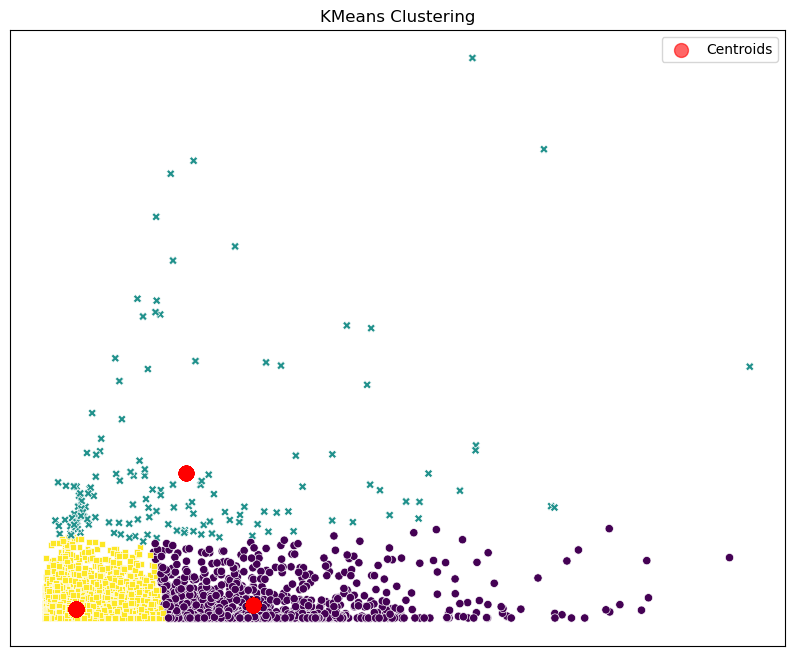

In [89]:
# k = 3

kmeans = KMeans(n_clusters=3)
kmeans.fit(X_train)
centroids, cluster_idxs = kmeans.evaluate(X_train)

# Plot the clusters using Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train.iloc[:, 0], y=X_train.iloc[:, 1], hue=cluster_idxs, palette='viridis', style=cluster_idxs , legend = None)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, alpha=0.6, label='Centroids')
plt.title("KMeans Clustering")
plt.legend()
plt.gca().axes.get_xaxis().set_visible(False)
plt.gca().axes.get_yaxis().set_visible(False)
plt.show()

Initial Centroids: [[ 3.61401636 -0.06608428]
 [ 1.30766212 19.23344691]
 [ 3.11767056  2.90370799]
 [ 8.21455523 18.20740759]]
Iteration 1: Centroids:
 [[-0.03307123 -0.2087964 ]
 [ 1.52965302 14.41612678]
 [ 0.31739996  2.00219867]
 [ 7.06067441 14.28752325]]
Iteration 2: Centroids:
 [[-0.06950681 -0.20692726]
 [ 1.32067315 12.26891928]
 [ 0.72563397  1.94903498]
 [ 6.30580749 17.01917489]]
Iteration 3: Centroids:
 [[-0.12458303 -0.20277242]
 [ 1.57694653 11.12700478]
 [ 1.21855087  1.69655984]
 [ 3.14327984 19.30865262]]
Iteration 4: Centroids:
 [[-0.22090897 -0.18919151]
 [ 1.84107397 10.29332821]
 [ 1.67729351  1.16556683]
 [ 2.65234691 18.64150301]]
Iteration 5: Centroids:
 [[-0.30292457 -0.15890616]
 [ 1.64456111  9.22136201]
 [ 1.84813166  0.70417443]
 [ 2.4958786  17.99459537]]
Iteration 6: Centroids:
 [[-0.33432126 -0.13143268]
 [ 1.25916699  7.58184225]
 [ 1.89816043  0.42860298]
 [ 2.2690027  17.44958131]]
Iteration 7: Centroids:
 [[-0.34374907 -0.11229245]
 [ 1.16060152  6

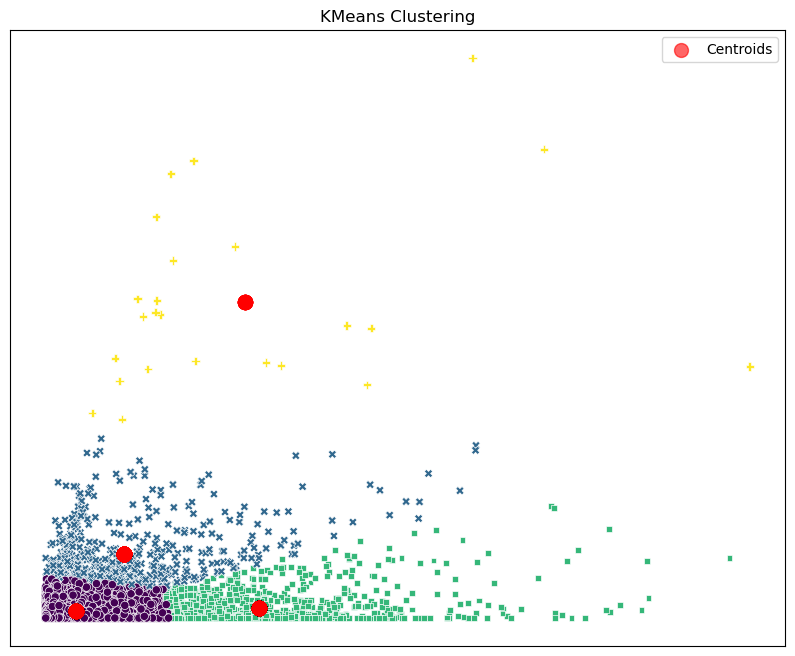

In [90]:
# k = 4
kmeans = KMeans(n_clusters=4)
kmeans.fit(X_train)
centroids, cluster_idxs = kmeans.evaluate(X_train)

# Plot the clusters using Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train.iloc[:, 0], y=X_train.iloc[:, 1], hue=cluster_idxs, palette='viridis', style=cluster_idxs , legend = None)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, alpha=0.6, label='Centroids')
plt.title("KMeans Clustering")
plt.legend()
plt.gca().axes.get_xaxis().set_visible(False)
plt.gca().axes.get_yaxis().set_visible(False)
plt.show()

## DIMENSIONALITY REDUCTION  (PCA)

In [91]:
df_scaled.head()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
0,-0.732054,-0.249881,-0.424934,-0.356957,-0.349114,-0.466805,-0.806649,-0.678716,-0.707409,-0.675294,-0.476083,-0.511381,-0.960380,-0.529026,-0.303869,-0.525588,0.360541
1,0.786858,0.134049,-0.469584,-0.356957,-0.454607,2.605438,-1.221928,-0.678716,-0.917090,0.573949,0.110032,-0.591841,0.688601,0.818546,0.093483,0.234159,0.360541
2,0.447041,0.517980,-0.107716,0.108843,-0.454607,-0.466805,1.269742,2.673295,-0.917090,-0.675294,-0.476083,-0.109082,0.826016,-0.383857,-0.096095,-0.525588,0.360541
3,0.049015,-1.017743,0.231995,0.546123,-0.454607,-0.368678,-1.014290,-0.399383,-0.917090,-0.258882,-0.329554,-0.551611,0.826016,-0.598733,-0.201502,-0.525588,0.360541
4,-0.358849,0.517980,-0.462095,-0.347317,-0.454607,-0.466805,-1.014290,-0.399383,-0.917090,-0.675294,-0.476083,-0.551611,-0.905414,-0.364421,-0.259023,-0.525588,0.360541


In [92]:
### PCA 
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(df_scaled)

X_train_pca = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
X_train_pca.head()

,PC1,PC2
0,-1.683714,-1.072995
1,-1.135338,2.507300
2,0.969119,-0.383383
3,-0.886751,0.008191
4,-1.600179,-0.684146


In [93]:
class KMeans:
    def __init__(self, n_clusters=8, max_iter=300, n_init=3, random_state=0):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.n_init = n_init
        self.random_state = random_state
    
    def fit(self, X_train_pca):
        # Convert DataFrame to numpy array
        X_train_pca = X_train_pca.values
        
        # Randomly select centroid start points
        min_, max_ = np.min(X_train_pca, axis=0), np.max(X_train_pca, axis=0)
        self.centroids = np.array([np.random.uniform(min_, max_) for _ in range(self.n_clusters)])
        
        print("Initial Centroids:", self.centroids)
        
        # Iterate, adjusting centroids until converged or until passes max_iter
        iteration = 0
        prev_centroids = None
        while prev_centroids is None or np.not_equal(self.centroids, prev_centroids).any() and iteration < self.max_iter:
            # Sort each data point, assigning to nearest centroid
            sorted_points = [[] for _ in range(self.n_clusters)]
            for x in X_train_pca:
                dists = euclidean(x, self.centroids)
                centroid_idx = np.argmin(dists)
                sorted_points[centroid_idx].append(x)
            
            # Push current centroid to previous, reassign centroids as mean of the points
            prev_centroids = self.centroids
            self.centroids = np.array([np.mean(cluster, axis=0) if len(cluster) > 0 else prev_centroids[i] for i, cluster in enumerate(sorted_points)])
            iteration += 1
            
            print(f"Iteration {iteration}: Centroids:\n", self.centroids)
    
    def evaluate(self, X):
        X = X.values
        centroids = []
        centroid_idxs = []
        for x in X:
            dists = euclidean(x, self.centroids)
            centroid_idx = np.argmin(dists)
            centroids.append(self.centroids[centroid_idx])
            centroid_idxs.append(centroid_idx)
        return np.array(centroids), centroid_idxs


In [94]:
# Euclidean function
def euclidean(point, data):
  """
  Euclidean distance between point and data
  Point has dimension (n, )
  Data has dimension (m, n)
  Out will be of size (m, )
  """
  return np.sqrt(np.sum((point - data)**2, axis=1))

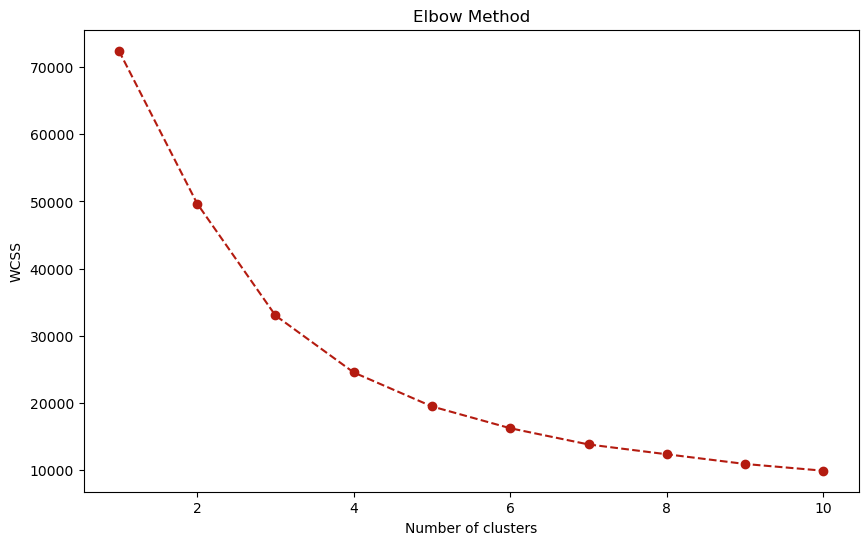

In [101]:
# Plot elbow
from sklearn.cluster import KMeans
# Calculate WCSS (within-cluster sum of squares) for different number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, max_iter=300, n_init=3, random_state=0)
    kmeans.fit(X_train_pca)
    wcss.append(kmeans.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Initial Centroids: [[19.44398279 -1.41059994]
 [ 8.04916237 10.5045007 ]]
Iteration 1: Centroids:
 [[ 1.47506697e+01  1.92655373e+00]
 [-7.28837134e-02 -9.51918744e-03]]
Iteration 2: Centroids:
 [[11.4418117   2.40298904]
 [-0.12407251 -0.02605749]]
Iteration 3: Centroids:
 [[ 9.24904466  2.12677865]
 [-0.17910213 -0.04118378]]
Iteration 4: Centroids:
 [[ 7.67056312  1.74732387]
 [-0.24136281 -0.05498149]]
Iteration 5: Centroids:
 [[ 6.37761001  1.2975108 ]
 [-0.32427256 -0.06597254]]
Iteration 6: Centroids:
 [[ 5.50011363  1.05255674]
 [-0.40587592 -0.07767247]]
Iteration 7: Centroids:
 [[ 4.9571726   0.82710336]
 [-0.47133176 -0.07864162]]
Iteration 8: Centroids:
 [[ 4.56258289  0.63405823]
 [-0.52787395 -0.07335819]]
Iteration 9: Centroids:
 [[ 4.25367659  0.46090231]
 [-0.57950673 -0.06279179]]
Iteration 10: Centroids:
 [[ 4.03318719  0.35910591]
 [-0.61917066 -0.05512956]]
Iteration 11: Centroids:
 [[ 3.88634923  0.2924889 ]
 [-0.6468806  -0.04868461]]
Iteration 12: Centroids:
 [[

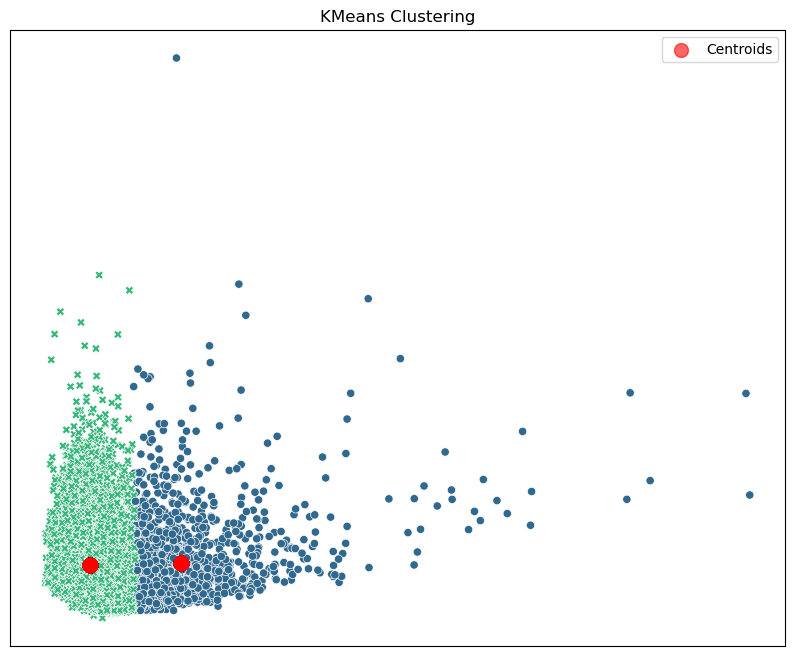

In [96]:
# k =2
kmeans = KMeans(n_clusters=2)
kmeans.fit(X_train_pca)
centroids, cluster_idxs = kmeans.evaluate(X_train_pca)

# Plot the clusters using Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train_pca.iloc[:, 0], y=X_train_pca.iloc[:, 1], hue=cluster_idxs, palette='viridis', style=cluster_idxs , legend = None)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, alpha=0.6, label='Centroids')
plt.title("KMeans Clustering")
plt.legend()
plt.gca().axes.get_xaxis().set_visible(False)
plt.gca().axes.get_yaxis().set_visible(False)
plt.show()


Initial Centroids: [[ 9.07950413  2.22246226]
 [27.50437513 20.89324333]
 [17.54303155 17.80554957]]
Iteration 1: Centroids:
 [[-1.60068718e-02 -9.82436718e-03]
 [ 2.95160297e+01  6.02071340e+00]
 [ 1.40142302e+01  1.26330400e+01]]
Iteration 2: Centroids:
 [[-0.06670784 -0.02986426]
 [24.45819748  4.8153482 ]
 [11.74701881  6.45176762]]
Iteration 3: Centroids:
 [[-0.13781953 -0.04755217]
 [22.68007702  4.61158097]
 [ 9.00007125  3.39747563]]
Iteration 4: Centroids:
 [[-0.23340564 -0.06882469]
 [20.4250268   3.99708642]
 [ 6.77142364  2.12582715]]
Iteration 5: Centroids:
 [[-0.35859508 -0.08827956]
 [18.27319853  3.75969939]
 [ 5.22851803  1.32478426]]
Iteration 6: Centroids:
 [[-0.47638411 -0.09025069]
 [17.38787476  4.35973796]
 [ 4.40004543  0.79334798]]
Iteration 7: Centroids:
 [[-0.5854806  -0.07568855]
 [16.82729957  4.17934471]
 [ 3.81100478  0.43245772]]
Iteration 8: Centroids:
 [[-0.65922738 -0.05347657]
 [15.96726609  3.98444587]
 [ 3.46264902  0.20327748]]
Iteration 9: Centro

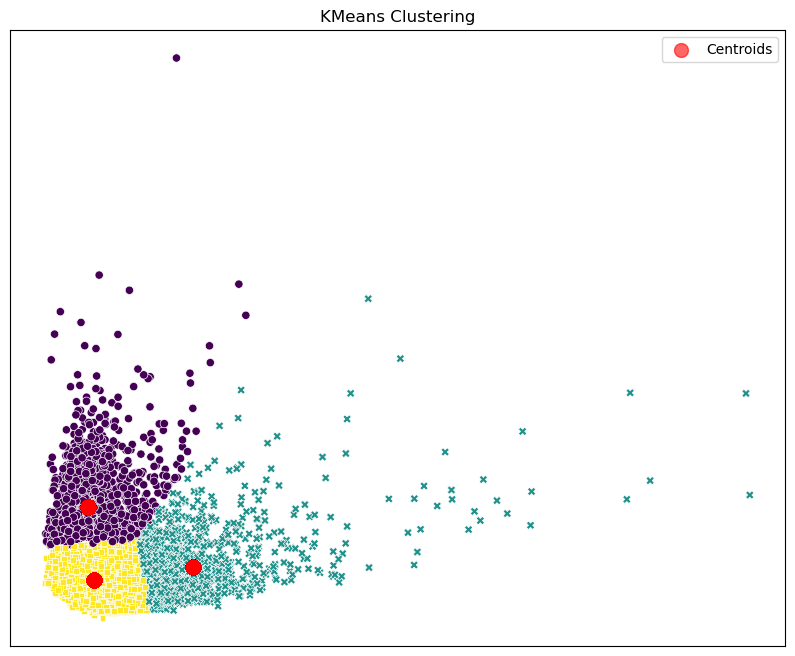

In [97]:
# k =3
kmeans = KMeans(n_clusters=3)
kmeans.fit(X_train_pca)
centroids, cluster_idxs = kmeans.evaluate(X_train_pca)

# Plot the clusters using Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train_pca.iloc[:, 0], y=X_train_pca.iloc[:, 1], hue=cluster_idxs, palette='viridis', style=cluster_idxs , legend = None)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, alpha=0.6, label='Centroids')
plt.title("KMeans Clustering")
plt.legend()
plt.gca().axes.get_xaxis().set_visible(False)
plt.gca().axes.get_yaxis().set_visible(False)
plt.show()


Initial Centroids: [[ 6.83279309 12.70468591]
 [16.23300632  2.13562128]
 [ 1.82194991 17.98804699]
 [10.35458552 20.17940508]]
Iteration 1: Centroids:
 [[-0.48956874  0.0975052 ]
 [ 3.87961477 -0.88243254]
 [-0.63212111 13.88544841]
 [10.35458552 20.17940508]]
Iteration 2: Centroids:
 [[-0.66254813 -0.02655425]
 [ 3.66820196 -0.30352611]
 [ 0.6325025   8.95146637]
 [18.60202669  9.89277084]]
Iteration 3: Centroids:
 [[-0.71413288 -0.16691488]
 [ 3.29614079 -0.32624766]
 [ 0.18866673  6.36765949]
 [17.27972989  4.55219265]]
Iteration 4: Centroids:
 [[-0.76542816 -0.31069998]
 [ 3.05016012 -0.43766072]
 [-0.16437626  4.97672198]
 [15.96726609  3.98444587]]
Iteration 5: Centroids:
 [[-0.79496495 -0.42837128]
 [ 2.86709775 -0.52125811]
 [-0.38970712  4.19067956]
 [14.55296278  3.15671758]]
Iteration 6: Centroids:
 [[-0.81793068 -0.51729666]
 [ 2.71289518 -0.58623002]
 [-0.53415212  3.71844813]
 [13.30511582  2.85420417]]
Iteration 7: Centroids:
 [[-0.83022873 -0.57314715]
 [ 2.60197245 -0

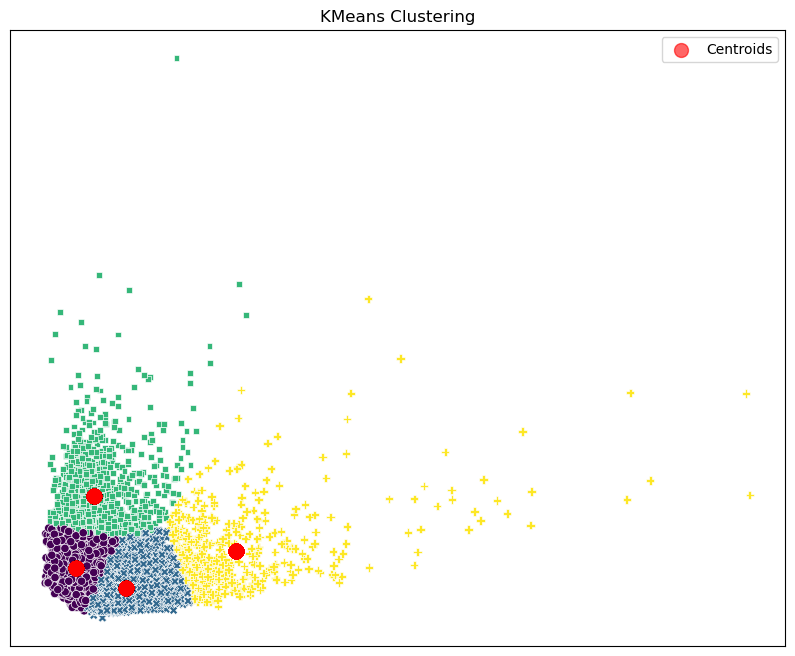

In [98]:
# k =4
kmeans = KMeans(n_clusters=4)
kmeans.fit(X_train_pca)
centroids, cluster_idxs = kmeans.evaluate(X_train_pca)

# Plot the clusters using Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train_pca.iloc[:, 0], y=X_train_pca.iloc[:, 1], hue=cluster_idxs, palette='viridis', style=cluster_idxs , legend = None)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, alpha=0.6, label='Centroids')
plt.title("KMeans Clustering")
plt.legend()
plt.gca().axes.get_xaxis().set_visible(False)
plt.gca().axes.get_yaxis().set_visible(False)
plt.show()


Initial Centroids: [[14.24861365 19.51226697]
 [ 9.68647356 18.41957991]
 [-0.0730528   5.24934751]
 [13.36928379 13.02185072]
 [28.86995622 18.29855403]]
Iteration 1: Centroids:
 [[ 1.42486136e+01  1.95122670e+01]
 [ 5.26456300e+00  1.72899204e+01]
 [-6.44448857e-02 -2.19165038e-02]
 [ 1.50126780e+01  3.95388963e+00]
 [ 2.70396984e+01  6.20835792e+00]]
Iteration 2: Centroids:
 [[12.06131955 13.30574293]
 [ 1.82463087 11.73074092]
 [-0.11648288 -0.05135151]
 [11.15681794  2.1909317 ]
 [26.42216873  5.61867591]]
Iteration 3: Centroids:
 [[12.28496884 10.72698617]
 [ 0.71739676  8.0786862 ]
 [-0.19176221 -0.12179741]
 [ 8.43571581  1.18948462]
 [23.79583724  5.04614866]]
Iteration 4: Centroids:
 [[ 1.05805289e+01  1.11877874e+01]
 [ 1.07322135e-02  5.71396277e+00]
 [-2.92285290e-01 -2.63337753e-01]
 [ 6.31282004e+00  5.16327122e-01]
 [ 2.10710169e+01  4.06911417e+00]]
Iteration 5: Centroids:
 [[ 8.17669872 10.41405793]
 [-0.34577095  4.46062015]
 [-0.41228769 -0.42501776]
 [ 4.94630112  

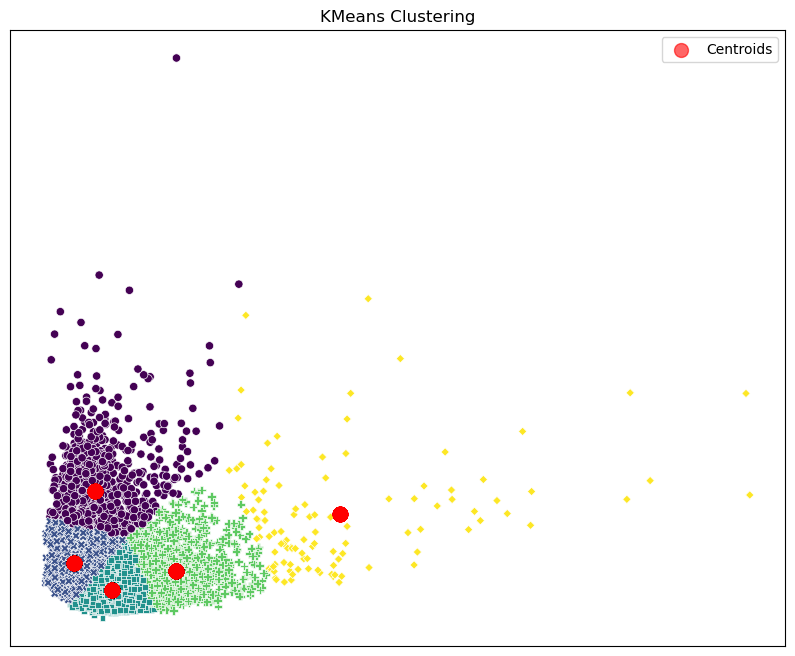

In [99]:
# k =5
kmeans = KMeans(n_clusters=5)
kmeans.fit(X_train_pca)
centroids, cluster_idxs = kmeans.evaluate(X_train_pca)

# Plot the clusters using Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train_pca.iloc[:, 0], y=X_train_pca.iloc[:, 1], hue=cluster_idxs, palette='viridis', style=cluster_idxs , legend = None)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, alpha=0.6, label='Centroids')
plt.title("KMeans Clustering")
plt.legend()
plt.gca().axes.get_xaxis().set_visible(False)
plt.gca().axes.get_yaxis().set_visible(False)
plt.show()
